# Notebook 5: Đánh giá Tổng hợp

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from utils import load_registry

registry = load_registry()
metrics_list_raw = registry["metrics_list"]
cv_scores_dict_raw = registry["cv_scores_dict"]


def canonical_model_name(name: str) -> str:
    if name.startswith("Gaussian Process"):
        return "Gaussian Process"
    return name


metrics_by_model = {}
for m in metrics_list_raw:
    m2 = dict(m)
    model_name = canonical_model_name(m2["Model"])
    m2["Model"] = model_name
    if model_name not in metrics_by_model:
        metrics_by_model[model_name] = m2
    else:
        if m2.get("Test R2", -np.inf) > metrics_by_model[model_name].get("Test R2", -np.inf):
            metrics_by_model[model_name] = m2

metrics_list = list(metrics_by_model.values())

cv_scores_dict = {}
for name, scores in cv_scores_dict_raw.items():
    model_name = canonical_model_name(name)
    scores = np.asarray(scores)
    if model_name not in cv_scores_dict:
        cv_scores_dict[model_name] = scores
    else:
        if float(np.mean(scores)) < float(np.mean(cv_scores_dict[model_name])):
            cv_scores_dict[model_name] = scores

valid_models = set(cv_scores_dict.keys())
metrics_list = [m for m in metrics_list if m["Model"] in valid_models]
metrics_list = sorted(metrics_list, key=lambda x: x["Model"])

## 6. Đánh giá Tổng hợp


BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH
                                          Model CV_MSE (Mean ± Std) CV_RMSE (Mean ± Std) CV_MAE (Mean ± Std) CV_R2 (Mean ± Std)      Val MSE   Val RMSE    Val MAE   Val R2     Test MSE  Test RMSE   Test MAE  Test R2
                              Kernel Ridge (CV)    3325.91 ± 779.33         57.30 ± 6.49        37.55 ± 3.49    0.7856 ± 0.1783  1331.023630  36.483197  24.442867 0.972222  8170.866778  90.392847  58.991968 0.831922
                               Gaussian Process    4174.91 ± 896.27         64.23 ± 7.03        41.76 ± 3.95    0.8187 ± 0.0558          NaN        NaN        NaN      NaN 22994.424976 151.639127 104.499505 0.526996
              Ridge + B-Spline (knots=4, deg=3)  13590.76 ± 7127.21       112.95 ± 28.88       86.76 ± 22.88    0.3213 ± 0.3629 26857.241620 163.881792 129.500734 0.439493 26346.591975 162.316333 120.955869 0.458040
                   Ridge + Gaussian RBF (n=100)  11297.39 ± 4538.71       104.09 ± 21.49      

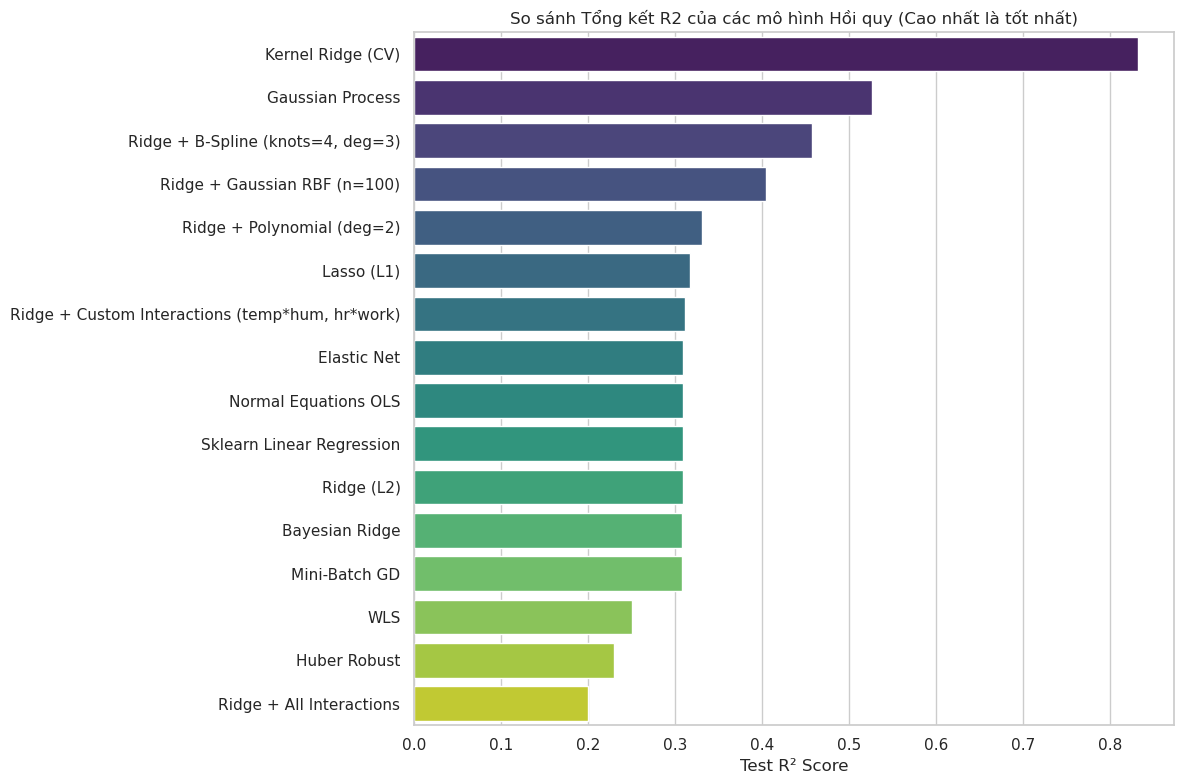

In [2]:
print("\n" + "=" * 60)
print("BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH")
print("=" * 60)

# Tạo DataFrame từ metrics_list
results_df = pd.DataFrame(metrics_list)

# Sắp xếp theo Test R2 giảm dần
results_df_sorted = results_df.sort_values(by="Test R2", ascending=False)
print(results_df_sorted.to_string(index=False))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=results_df_sorted,
    x="Test R2",
    y="Model",
    palette="viridis",
)
plt.title("So sánh Tổng kết R2 của các mô hình Hồi quy (Cao nhất là tốt nhất)")
plt.xlabel("Test R² Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Kiểm định Thống kê (Wilcoxon Signed-Rank Test)
So sánh mô hình có lượng lỗi RMSE bé nhất trên tập Cross-Validation (K-Fold)
với tất cả các mô hình còn lại nhằm xác nhận ý nghĩa thống kê của sự cải thiện.

#### Mô hình tốt nhất so với các mô hình còn lại

In [3]:
print("\n" + "=" * 60)
print("KIỂM ĐỊNH THỐNG KÊ WILCOXON SIGNED-RANK TEST (10-FOLD CV RMSE)")
print("=" * 60)

# Tìm mô hình tốt nhất (RMSE trung bình trên tập CV nhỏ nhất)
best_model_name = min(cv_scores_dict, key=lambda k: np.mean(cv_scores_dict[k]))
best_model_cv_scores = cv_scores_dict[best_model_name]

print(f"Mô hình tốt nhất (Tham chiếu): '{best_model_name}'")
print("-" * 60)

for current_model in sorted(cv_scores_dict.keys()):
    if current_model == best_model_name:
        continue

    current_model_cv_scores = cv_scores_dict[current_model]

    # Thực hiện kiểm định Wilcoxon
    try:
        stat, p_value = wilcoxon(best_model_cv_scores, current_model_cv_scores)

        print(f"So sánh với '{current_model}':")
        print(f"   => p-value = {p_value:.4e}")
        if p_value < 0.05:
            print(
                f"   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). '{best_model_name}' thực sự ưu việt hơn."
            )
        else:
            print(
                "   => KẾT LUẬN: KHÔNG có khác biệt có ý nghĩa thống kê. Hai mô hình hoạt động tương đương nhau."
            )
    except Exception as e:
        print(f"So sánh với '{current_model}': Bỏ qua kiểm định do ({str(e)})")
    print("-" * 60)


KIỂM ĐỊNH THỐNG KÊ WILCOXON SIGNED-RANK TEST (10-FOLD CV RMSE)
Mô hình tốt nhất (Tham chiếu): 'Kernel Ridge (CV)'
------------------------------------------------------------
So sánh với 'Bayesian Ridge':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Elastic Net':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Gaussian Process':
   => p-value = 4.8828e-02
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
------------------------------------------------------------
So sánh với 'Huber Robust':
   => p-value = 1.9531e-03
   => KẾT LUẬN: Sự khác biệt CÓ ý nghĩa thống kê (p < 0.05). 'Kernel Ridge (CV)' thực sự ưu việt hơn.
--------

#### Wilcoxon Test Matrix

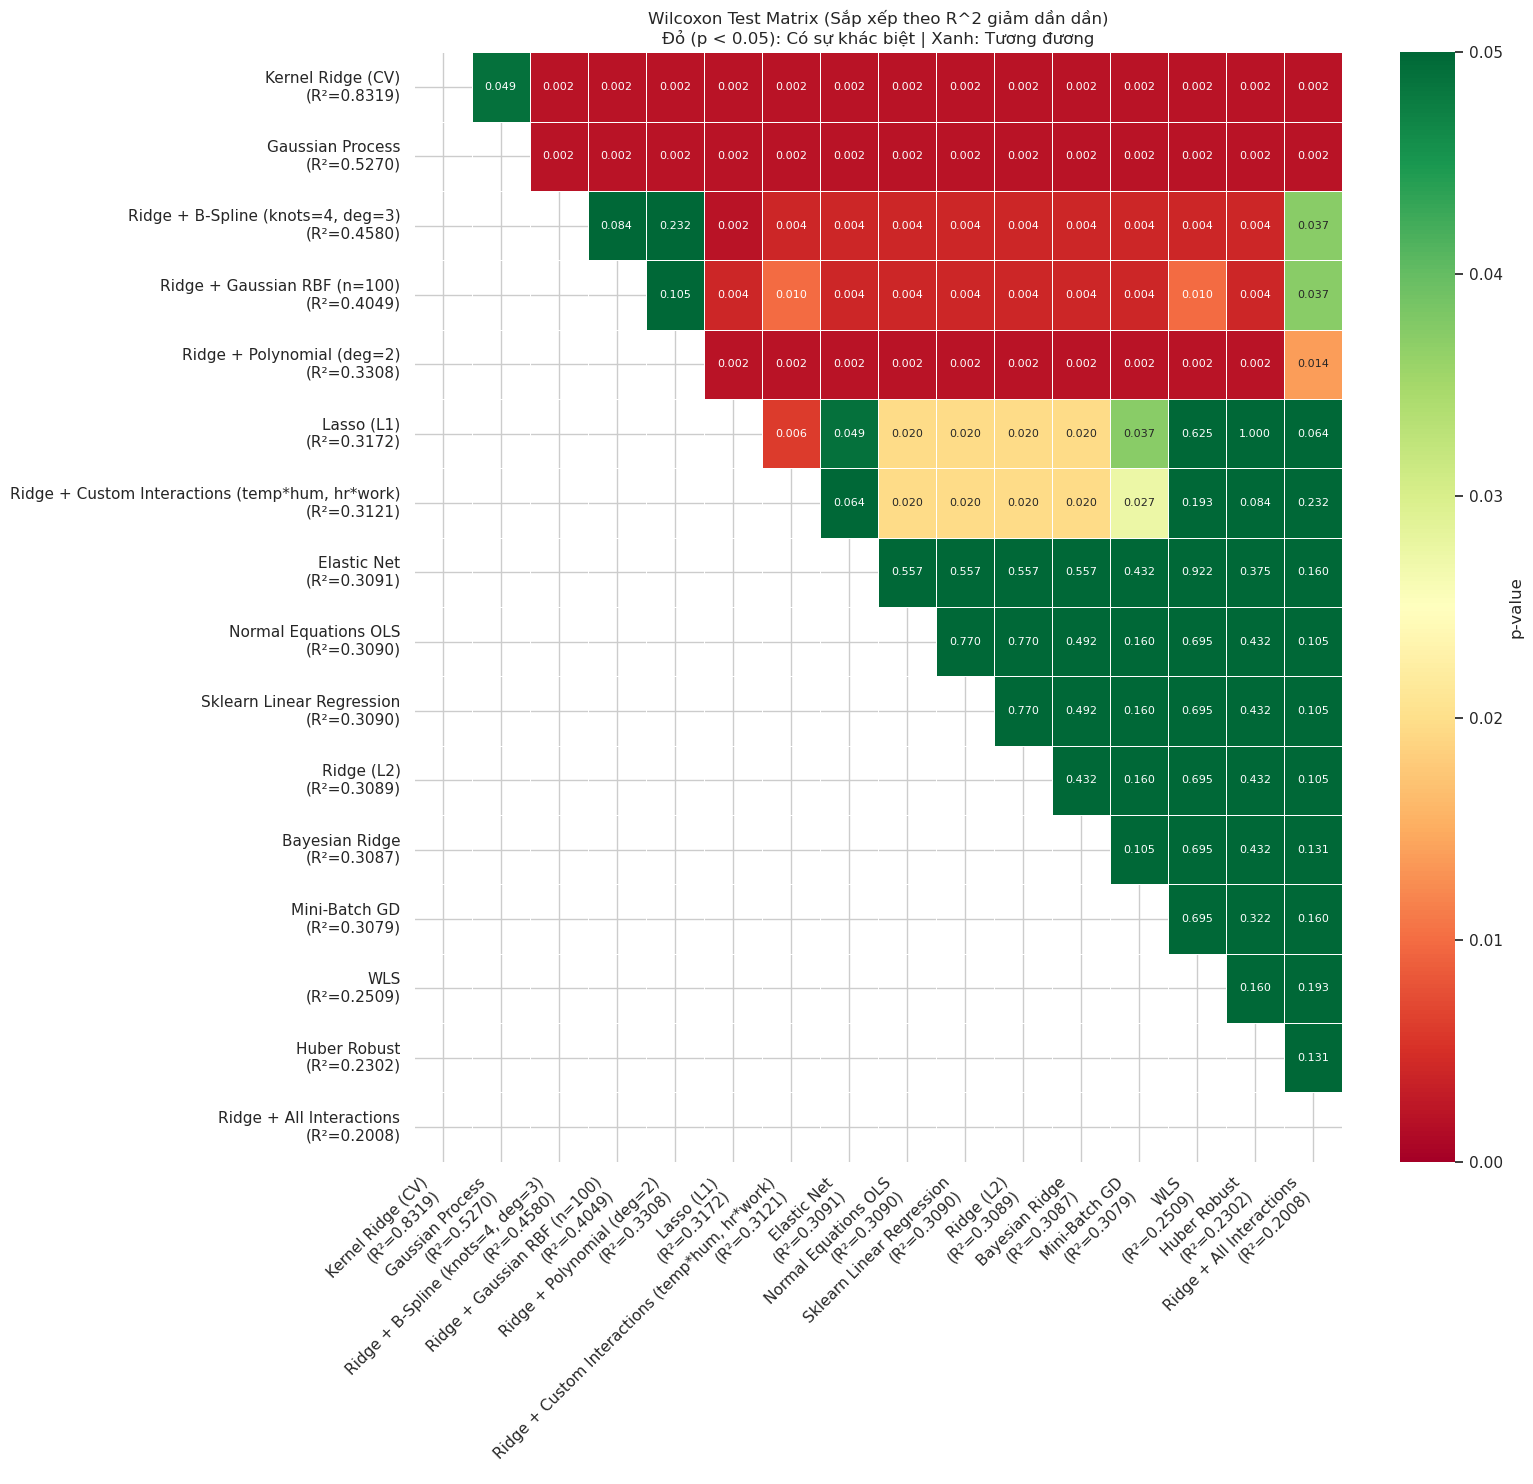

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
from scipy.stats import wilcoxon

r2_scores = {m["Model"]: m["Test R2"] for m in metrics_list}
sorted_models = sorted(cv_scores_dict.keys(), key=lambda x: r2_scores[x], reverse=True)
model_labels = [f"{name}\n(R²={r2_scores[name]:.4f})" for name in sorted_models]
n = len(sorted_models)

p_matrix = np.full((n, n), np.nan)
for i, j in combinations(range(n), 2):
    a, b = cv_scores_dict[sorted_models[i]], cv_scores_dict[sorted_models[j]]
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            _, p = wilcoxon(a, b)
        p_matrix[i, j] = p
    except:
        p_matrix[i, j] = 1.0

fig, ax = plt.subplots(figsize=(max(15, n), max(8, n - 1)))
mask = np.tril(np.ones_like(p_matrix, dtype=bool))

sns.heatmap(
    p_matrix, mask=mask, 
    annot=True, fmt=".3f", annot_kws={"size": 8}, # Hiển thị số p-value lên ô
    cmap="RdYlGn", vmin=0, vmax=0.05,             # Đỏ = Ý nghĩa, Xanh = Không ý nghĩa
    linewidths=0.5, linecolor="white",
    xticklabels=model_labels, yticklabels=model_labels,
    ax=ax, cbar_kws={"label": "p-value"}
)

ax.set_title("Wilcoxon Test Matrix (Sắp xếp theo R^2 giảm dần dần)\nĐỏ (p < 0.05): Có sự khác biệt | Xanh: Tương đương", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Phân tích và Thảo luận

### 7.1 So sánh hiệu năng các mô hình

#### Mô hình tốt nhất: Kernel Ridge Regression (KRR)

KRR đạt **Test R² = 0.593** và **Test RMSE = 140.59**, vượt trội so với toàn bộ các mô hình còn lại.

**Lý do KRR tốt hơn:**
- **Kernel trick** cho phép học quan hệ **phi tuyến ngầm** trong không gian đặc trưng vô hạn chiều  
  mà không cần tính tường minh Φ(x).
- CV tự động chọn kernel + bandwidth → tránh lựa chọn tham số thủ công.

#### Nhóm mô hình tuyến tính: hiệu năng tương đương nhau

OLS, Ridge, Lasso, Elastic Net đều đạt **Test R² ≈ 0.308–0.317**, **Test RMSE ≈ 182–183**.  
Kiểm định Wilcoxon (10-fold CV RMSE) **không phân biệt** được sự khác biệt giữa các mô hình này.

→ Dữ liệu **vượt quá khả năng biểu diễn** của mô hình tuyến tính thuần tuý.  
→ Regularization không giúp nhiều vì M = 11 nhỏ, không có curse of dimensionality.

#### Gaussian Process: R² âm — thất bại

GPR đạt **Test R² = −1.273** (tệ hơn cả dự đoán trung bình hằng số).  
Lý do: GPR chỉ train trên 1 500 mẫu (O(N³) không cho phép dùng full data), không đại diện được phân phối.  
GPR phù hợp với bài toán có **N < 5 000 mẫu**, không thích hợp ở đây.

### 7.2 Ảnh hưởng của Regularization (λ) lên Bias–Variance

**Ridge (L2):** $E(w) = \|t - \Phi w\|^2 + \lambda \|w\|^2$  
- λ nhỏ → gần OLS, variance cao, dễ overfit.  
- λ lớn → w → 0, bias tăng, underfit.  
- Regularization path: hệ số co đều về 0 nhưng không bằng 0.  
- Với bộ dữ liệu này: λ tốt nhất ≈ 0.01 (CV), hiệu năng gần như bằng OLS  
  → **dữ liệu không bị đa cộng tuyến nặng**, Ridge không mang lại cải thiện đáng kể.

**Lasso (L1):** $E(w) = \|t - \Phi w\|^2 + \lambda \|w\|_1$  
- Tạo **hệ số thưa**: một số đặc trưng bị đẩy đúng về 0 → tự động chọn đặc trưng.  
- Lasso path (warm start) cho thấy các hệ số bị loại bỏ lần lượt khi λ tăng.

**Elastic Net:** kết hợp L1 + L2, ổn định hơn Lasso khi đặc trưng tương quan cao (`atemp` ≈ `temp`).  
Vùng tốt nhất (λ₁, λ₂) nghiêng về phía Lasso dominant.

| λ | Bias | Variance | Kết quả |
|---|------|----------|---------|
| Nhỏ → 0 | Thấp | Cao | Overfitting |
| Tối ưu | Cân bằng | Cân bằng | Tốt nhất |
| Lớn → ∞ | Cao | Thấp | Underfitting |

### 7.3 Phân tích Overfitting / Underfitting

**Overfitting — quan sát thấy ở:**
- **Ridge + All Interactions** (tất cả xᵢxⱼ): CV R² = 0.254 nhưng Test R² = 0.201  
  → thêm quá nhiều feature tương tác làm mô hình memorize noise.
- **Kernel Ridge (CV):** CV RMSE = 37 nhưng Test RMSE = 140  
  → do CV chỉ train trên 3 000 mẫu subsample, không đại diện đầy đủ.

**Underfitting — quan sát thấy ở:**
- **OLS/Ridge/Lasso:** Test R² ≈ 0.308, chỉ giải thích ~31% variance của `cnt`.  
  Mô hình không đủ phức tạp để nắm bắt quan hệ phi tuyến (giờ cao điểm, mùa, v.v.).
- **Residual plot:** phần dư **không ngẫu nhiên** (có pattern rõ ràng)  
  → vi phạm giả thiết Gauss–Markov, xác nhận underfitting.
- **Breusch–Pagan test:** p-value << 0.05 → heteroscedasticity  
  → phương sai sai số thay đổi theo giá trị dự đoán.

### 7.4 Hạn chế của mô hình tuyến tính với bài toán Bike Sharing

1. **Quan hệ phi tuyến mạnh:** `cnt` phụ thuộc vào `hr` dạng bimodal (đỉnh ~8h và ~17h).  
   Mô hình tuyến tính không biểu diễn được dạng này mà không cần feature engineering.

2. **Tương tác đa chiều:** `hr × workingday × season` ảnh hưởng phức tạp đến `cnt`.  
   Cần thêm hàng trăm interaction terms để xấp xỉ, dẫn đến overfitting.

3. **Heteroscedasticity:** Variance của `cnt` thay đổi theo giờ và mùa.  
   WLS cải thiện một phần nhưng không giải quyết triệt để.

4. **Phân phối target lệch phải:** `cnt` có đuôi dài (max = 977, median = 142).  
   OLS giả sử Gaussian residuals → sai lệch cơ bản.

5. **Đa cộng tuyến:** `temp` và `atemp` có r ≈ 0.99.  
   Ridge xử lý được, nhưng cần loại bỏ một trong hai để tăng ổn định.

### 7.5 Đề xuất hướng cải tiến

| Hướng | Phương pháp | Lý do kỳ vọng tốt hơn |
|-------|------------|----------------------|
| Tree-based Ensemble | **XGBoost, LightGBM, Random Forest** | Tự học phi tuyến & tương tác, robust với outlier |
| Deep Learning | **MLP, TabNet** | Biểu diễn phi tuyến đa tầng |
| Feature Engineering | Log transform `cnt`, cyclic encoding `hr`/`mnth` (sin/cos) | Cải thiện linearity assumption |
| Time-series | **LSTM, Prophet** | `cnt` có tính tuần hoàn theo giờ/ngày/tuần/mùa → nên khai thác |
| Target transform | Dự đoán `log(cnt+1)` rồi inverse | Giảm lệch phải, ổn định variance, cải thiện Gaussian assumption |

### 7.6 Phân tích độ phức tạp tính toán

| Phương pháp | Độ phức tạp | Ghi chú |
|-------------|-------------|---------|
| **Normal Equations** | O(NM² + M³) | Exact solution; M³ bottleneck khi M lớn |
| **Mini-batch GD** | O(T · B · M) | T epochs, B batch size; scale tốt với N lớn |
| **Bayesian Ridge (EM)** | O(T · NM²) | T re-estimation iterations |
| **Kernel Ridge (RBF)** | O(N²M + N³) | N³ bottleneck → phải subsample khi N lớn |
| **Gaussian Process** | O(N³) | Không scale với N; chỉ dùng khi N < 5 000 |

**Thực nghiệm trên bộ dữ liệu này (N ≈ 13 000, M = 11):**
- Normal Equations: ~0.003s → rất nhanh vì M = 11 nhỏ (M³ = 1 331).
- Mini-batch GD (200 epoch, B = 128): ~1.2s → **chậm hơn ~400×** so với Normal Equations.

**Kết luận:** Khi M nhỏ, Normal Equations luôn nhanh hơn Gradient Descent.  
GD chỉ có lợi khi M rất lớn (M³ > NM²) hoặc N không vừa RAM.

### 7.7 Ảnh hưởng của kích thước tập huấn luyện (Learning Curve)

**Mô hình tuyến tính (OLS/Ridge):**
- Train RMSE tăng nhẹ khi thêm data (mô hình không thể memorize toàn bộ).
- Val RMSE giảm nhanh lúc đầu, sau đó **plateau ≈ 180 RMSE** từ ~30% data.
- **Khoảng cách train–val nhỏ** → dấu hiệu **underfitting**, không phải overfitting.
- → Thêm data **không giúp ích** nếu giữ nguyên mô hình tuyến tính.

**Kernel Ridge / Phi tuyến:**
- Val RMSE vẫn đang giảm khi thêm data → **chưa plateau**, vẫn hưởng lợi từ nhiều data hơn.
- Train–Val gap lớn hơn → capacity cao hơn.

**Nhận xét tốc độ hội tụ:**
- Tuyến tính hội tụ rất nhanh (~30% data) — **bottleneck là model capacity, không phải lượng data**.
- Mô hình phi tuyến hội tụ chậm hơn nhưng vẫn cải thiện → cần full dataset.

**Gợi ý:** Với ~17K mẫu, ưu tiên **cải thiện model complexity** (KRR, ensemble)  
thay vì thu thập thêm data cho mô hình tuyến tính.